# PhishGuard AI - 01 Exploratory Data Analysis (EDA)
**Explainable AI-Based Phishing URL Detection and Risk Analysis System**

This notebook performs exploratory data analysis on the raw phishing and legitimate URL dataset.
We inspect shapes, missing values, duplicates, class distributions, and feature correlations.

In [6]:
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DEFAULT_RAW_DATASET_CSV
from src.data_loader import DatasetLoader
from src.preprocessing import DataPreprocessor

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Dataset and Inspect Schema

In [7]:
loader = DatasetLoader(filepath=DEFAULT_RAW_DATASET_CSV)
df = loader.load()
print(f"Dataset Shape: {df.shape}")
print(f"Detected URL Column: {loader.url_col}")
print(f"Detected Label Column: {loader.label_col}")
df.head(10)

2026-10-02 21:47:13,505 [INFO] DataLoader: Loading dataset from: C:\Users\mubas\OneDrive\Desktop\PB-Hackthon\data\raw\phishing_urls_dataset.csv
2026-10-02 21:47:13,514 [INFO] DataLoader: Dataset loaded successfully with shape: (2500, 2)
2026-10-02 21:47:13,516 [INFO] DataLoader: Detected URL column: 'url', Label column: 'label'


Dataset Shape: (2500, 2)
Detected URL Column: url
Detected Label Column: label


,url,label
0,https://status.chase.com/archive/2023/12/summa...,0
1,https://api.cam.ac.uk/contact,0
2,https://support.w3schools.com/products/catalog...,0
3,http://netflix.com.signin-center.work/signin.p...,1
4,https://blog.docker.com/explore/popular,0
5,https://api.github.com/features,0
6,https://status.cam.ac.uk,0
7,https://developer.ox.ac.uk/about,0
8,http://178.58.1.99/microsoft/signin.php?sessio...,1
9,http://crypto-wallet.com.claim-bonus-client.lo...,1


## 2. Summary Statistics, Missing Data, and Duplicates

In [8]:
print("Dataset Info:")
df.info()
print("\nMissing Values:\n", df.isna().sum())
duplicates = df.duplicated(subset=[loader.url_col]).sum()
print(f"\nDuplicate URLs: {duplicates} ({duplicates / len(df) * 100:.2f}%)")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     2500 non-null   str  
 1   label   2500 non-null   int64
dtypes: int64(1), str(1)
memory usage: 162.0 KB

Missing Values:
 url      0
label    0
dtype: int64

Duplicate URLs: 84 (3.36%)


## 3. Class Balance and Label Normalization

2026-10-02 21:47:13,556 [INFO] Preprocessing: Initial raw rows: 2500
2026-10-02 21:47:13,559 [INFO] Preprocessing: Rows after dropping nulls in critical columns: 2500
2026-10-02 21:47:13,565 [INFO] Preprocessing: Dropped 84 duplicate URL rows. Remaining: 2416
2026-10-02 21:47:13,604 [INFO] Preprocessing: Final cleaned dataset size: 2416
2026-10-02 21:47:13,605 [INFO] Preprocessing: Class Distribution -> Legitimate (0): 1182 (48.9%), Phishing (1): 1234 (51.1%)
C:\Users\mubas\AppData\Local\Temp\ipykernel_19680\794896227.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Legitimate (0)", "Phishing (1)"], y=class_counts.values, palette=["#10B981", "#EF4444"], ax=ax)


Cleaned Class Distribution:
 label_normalized
1    1234
0    1182
Name: count, dtype: int64


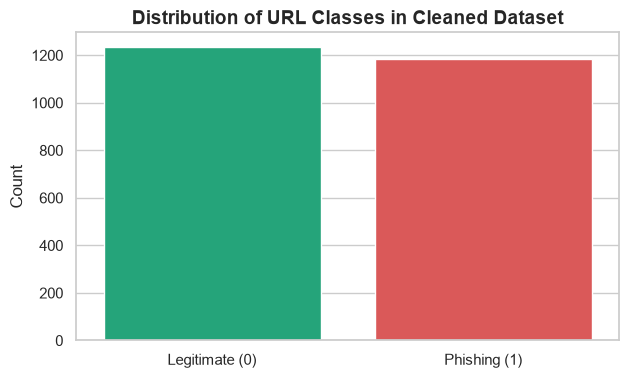

In [9]:
preprocessor = DataPreprocessor()
df_clean = preprocessor.clean_dataset(df, url_col=loader.url_col, label_col=loader.label_col)
class_counts = df_clean['label_normalized'].value_counts()
print("Cleaned Class Distribution:\n", class_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=["Legitimate (0)", "Phishing (1)"], y=class_counts.values, palette=["#10B981", "#EF4444"], ax=ax)
ax.set_title("Distribution of URL Classes in Cleaned Dataset", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
plt.show()

## 4. Lexical Feature Distributions: URL Length & Dot Counts

C:\Users\mubas\AppData\Local\Temp\ipykernel_19680\449986855.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_normalized', y='url_length', data=df_clean, palette=["#10B981", "#EF4444"], ax=axes[0])
C:\Users\mubas\AppData\Local\Temp\ipykernel_19680\449986855.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Legitimate", "Phishing"])
C:\Users\mubas\AppData\Local\Temp\ipykernel_19680\449986855.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_normalized', y='qty_dot', data=df_clean, palette=["#10B981", "#EF4444"], ax=axes[1

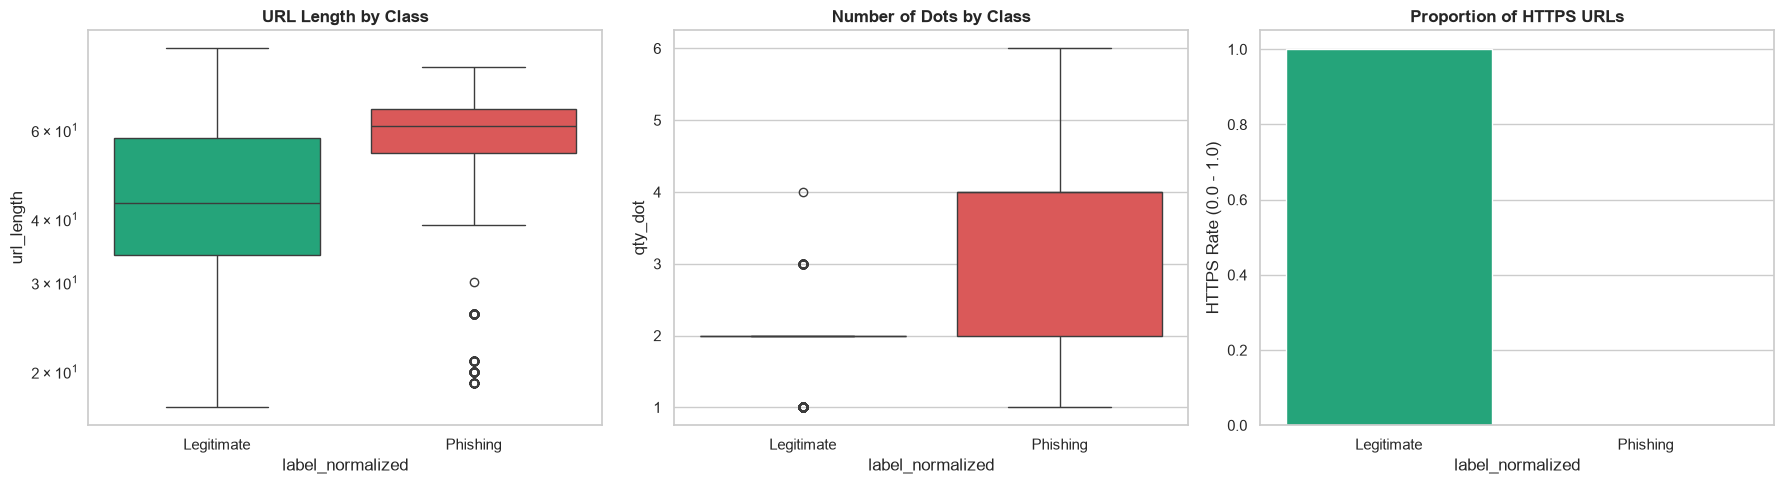

In [10]:
df_clean['url_length'] = df_clean[loader.url_col].apply(len)
df_clean['qty_dot'] = df_clean[loader.url_col].apply(lambda u: u.count('.'))
df_clean['is_https'] = df_clean[loader.url_col].apply(lambda u: 1 if u.startswith('https') else 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# URL Length
sns.boxplot(x='label_normalized', y='url_length', data=df_clean, palette=["#10B981", "#EF4444"], ax=axes[0])
axes[0].set_title("URL Length by Class", fontweight="bold")
axes[0].set_xticklabels(["Legitimate", "Phishing"])
axes[0].set_yscale('log')

# Dot Count
sns.boxplot(x='label_normalized', y='qty_dot', data=df_clean, palette=["#10B981", "#EF4444"], ax=axes[1])
axes[1].set_title("Number of Dots by Class", fontweight="bold")
axes[1].set_xticklabels(["Legitimate", "Phishing"])

# HTTPS Usage
sns.barplot(x='label_normalized', y='is_https', data=df_clean, palette=["#10B981", "#EF4444"], ax=axes[2])
axes[2].set_title("Proportion of HTTPS URLs", fontweight="bold")
axes[2].set_xticklabels(["Legitimate", "Phishing"])
axes[2].set_ylabel("HTTPS Rate (0.0 - 1.0)")

plt.tight_layout()
plt.show()